# Evaluasi Model V7 (Base vs Hybrid)

Notebook ini mengevaluasi model terbaru `v7` pada dua level prediksi:
- **Base model** (TF-IDF + Logistic Regression)
- **Hybrid model** (base + rules: negative/positive/contrast-to-neutral override)

Sumber evaluasi diambil dari artefak:
- `sentiment_model/model_artifacts_v7/metadata_v7.json`

Notebook ini menampilkan:
- ringkasan metrik Base vs Hybrid
- classification report per mode
- confusion matrix per mode
- interpretasi trade-off (negatif, netral, positif)

In [4]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sentiment_model.test_model import load_artifacts

In [7]:
MODEL_DIR = PROJECT_ROOT / 'sentiment_model' / 'model_artifacts_v8'
_, _, metadata, hybrid_config = load_artifacts(MODEL_DIR)

label_order = metadata.get('label_order', ['negatif', 'netral', 'positif'])
selection_metric = metadata.get('selection_metric', 'unknown')
best_model_name = metadata.get('best_model', 'unknown')

base_metrics = metadata.get('base_metrics', {})
hybrid_metrics = metadata.get('hybrid_metrics', {})

if not base_metrics or not hybrid_metrics:
    raise ValueError('Metadata v8 tidak lengkap. Pastikan training v8 sudah selesai.')

summary_df = pd.DataFrame(
    [
        {
            'mode': 'base_model',
            'accuracy': base_metrics.get('accuracy', np.nan),
            'macro_f1': base_metrics.get('macro_f1', np.nan),
            'negative_recall': base_metrics.get('negative_recall', np.nan),
            'neutral_recall': base_metrics.get('neutral_recall', np.nan),
            'positive_recall': base_metrics.get('positive_recall', np.nan),
        },
        {
            'mode': 'hybrid_model',
            'accuracy': hybrid_metrics.get('accuracy', np.nan),
            'macro_f1': hybrid_metrics.get('macro_f1', np.nan),
            'negative_recall': hybrid_metrics.get('negative_recall', np.nan),
            'neutral_recall': hybrid_metrics.get('neutral_recall', np.nan),
            'positive_recall': hybrid_metrics.get('positive_recall', np.nan),
        },
    ]
).sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)

print('Data source         :', metadata.get('data_path', 'unknown'))
print('Rows (preprocess)   :', metadata.get('rows_after_preprocessing', 'unknown'))
print('Train/Test rows     :', metadata.get('train_rows_before_rebalance', 'unknown'), '/', metadata.get('test_rows', 'unknown'))
print('Selection metric    :', selection_metric)
print('Best model name     :', best_model_name)
print('Hybrid enabled      :', bool(hybrid_config))
print()
summary_df

Data source         : D:\semester-4-IT Del\Semester VI\UI-UX DESIGN\Scrapping_Data\Merged_Excel\dataset_labeled_combined_v3.xlsx
Rows (preprocess)   : 1227
Train/Test rows     : 981 / 246
Selection metric    : macro_f1_then_neutral_recall_then_positive_then_negative_then_accuracy
Best model name     : logistic_regression_hybrid_v8
Hybrid enabled      : True



,mode,accuracy,macro_f1,negative_recall,neutral_recall,positive_recall
0,hybrid_model,0.817073,0.817522,0.768116,0.820225,0.852273
1,base_model,0.808943,0.807592,0.710145,0.842697,0.852273


## Interpretasi Hasil V8

Evaluasi V8 dilakukan pada dua mode output:
1. **Base model**: prediksi murni dari Logistic Regression
2. **Hybrid model**: prediksi base yang dapat di-override oleh rule

Urutan prioritas seleksi pada metadata V8:
1. `macro_f1`
2. `neutral_recall`
3. `positive_recall`
4. `negative_recall`
5. `accuracy`

Catatan penting:
- Jika `hybrid_reason = model_only`, berarti prediksi akhir sama dengan base model.
- Jika `hybrid_reason` berisi override, berarti rule layer aktif (misalnya `mixed_polarity_conflict_to_neutral`).

Mode                : base_model
Accuracy            : 0.8089
Macro F1            : 0.8076
Recall negatif      : 0.7101
Recall netral       : 0.8427
Recall positif      : 0.8523

Classification Report - base_model


,precision,recall,f1-score,support
negatif,0.907407,0.710145,0.796748,69.000000
netral,0.789474,0.842697,0.815217,89.000000
positif,0.773196,0.852273,0.810811,88.000000
accuracy,0.808943,0.808943,0.808943,0.808943
macro avg,0.823359,0.801705,0.807592,246.000000
weighted avg,0.816730,0.808943,0.808461,246.000000



Confusion Matrix - base_model


,negatif,netral,positif
negatif,49,9,11
netral,3,75,11
positif,2,11,75


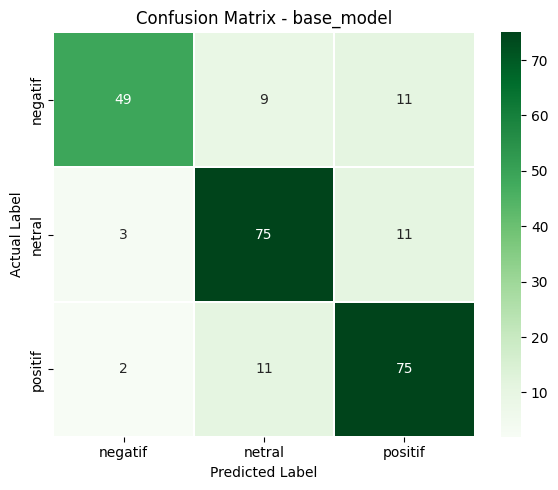

Mode                : hybrid_model
Accuracy            : 0.8171
Macro F1            : 0.8175
Recall negatif      : 0.7681
Recall netral       : 0.8202
Recall positif      : 0.8523

Classification Report - hybrid_model


,precision,recall,f1-score,support
negatif,0.883333,0.768116,0.821705,69.000000
netral,0.811111,0.820225,0.815642,89.000000
positif,0.781250,0.852273,0.815217,88.000000
accuracy,0.817073,0.817073,0.817073,0.817073
macro avg,0.825231,0.813538,0.817522,246.000000
weighted avg,0.820687,0.817073,0.817191,246.000000



Confusion Matrix - hybrid_model


,negatif,netral,positif
negatif,53,7,9
netral,4,73,12
positif,3,10,75


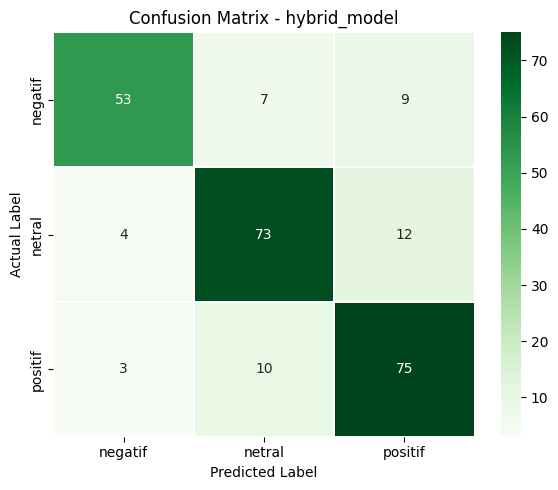

Delta (hybrid - base):


,metric,base_model,hybrid_model,hybrid_minus_base
0,accuracy,0.808943,0.817073,0.008130
1,macro_f1,0.807592,0.817522,0.009930
2,negative_recall,0.710145,0.768116,0.057971
3,neutral_recall,0.842697,0.820225,-0.022472
4,positive_recall,0.852273,0.852273,0.000000


In [8]:
mode_metrics = {
    'base_model': base_metrics,
    'hybrid_model': hybrid_metrics,
}

for mode_name in ['base_model', 'hybrid_model']:
    m = mode_metrics[mode_name]
    print(f"Mode                : {mode_name}")
    print(f"Accuracy            : {m['accuracy']:.4f}")
    print(f"Macro F1            : {m['macro_f1']:.4f}")
    print(f"Recall negatif      : {m['negative_recall']:.4f}")
    print(f"Recall netral       : {m['neutral_recall']:.4f}")
    print(f"Recall positif      : {m['positive_recall']:.4f}")
    print()

    print(f"Classification Report - {mode_name}")
    report_df = pd.DataFrame(m['classification_report']).transpose()
    display(report_df)
    print()

    print(f"Confusion Matrix - {mode_name}")
    cm = np.array(m['confusion_matrix'])
    cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
    display(cm_df)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap='Greens',
        cbar=True,
        linewidths=0.3,
        linecolor='white',
    )
    plt.title(f"Confusion Matrix - {mode_name}")
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.tight_layout()
    plt.show()

    print('=' * 80)

delta = pd.DataFrame(
    {
        'metric': ['accuracy', 'macro_f1', 'negative_recall', 'neutral_recall', 'positive_recall'],
        'base_model': [
            base_metrics['accuracy'],
            base_metrics['macro_f1'],
            base_metrics['negative_recall'],
            base_metrics['neutral_recall'],
            base_metrics['positive_recall'],
        ],
        'hybrid_model': [
            hybrid_metrics['accuracy'],
            hybrid_metrics['macro_f1'],
            hybrid_metrics['negative_recall'],
            hybrid_metrics['neutral_recall'],
            hybrid_metrics['positive_recall'],
        ],
    }
)
delta['hybrid_minus_base'] = delta['hybrid_model'] - delta['base_model']
print('Delta (hybrid - base):')
display(delta)